In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

In [2]:
PATH = 'slooze_challenge./'

sales     = pd.read_csv(PATH + 'SalesFINAL12312016.csv')
purchases = pd.read_csv(PATH + 'PurchasesFINAL12312016.csv')
beg_inv   = pd.read_csv(PATH + 'BegInvFINAL12312016.csv')
end_inv   = pd.read_csv(PATH + 'EndInvFINAL12312016.csv')
prices    = pd.read_csv(PATH + '2017PurchasePricesDec.csv')
abc       = pd.read_csv(PATH + 'abc_classified_products.csv')

sales['SalesDate'] = pd.to_datetime(sales['SalesDate'], format='mixed')
purchases['PODate'] = pd.to_datetime(purchases['PODate'])

for df in [sales, purchases, prices]:
    str_cols = df.select_dtypes('object').columns
    df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())

brand_cost = prices.groupby('Brand')['PurchasePrice'].median().reset_index()
brand_cost.columns = ['Brand','unit_cost']
sales = sales.merge(brand_cost, on='Brand', how='left')
sales['gross_profit'] = sales['SalesDollars'] - sales['unit_cost'] * sales['SalesQuantity']
sales['margin']       = sales['gross_profit'] / sales['SalesDollars'] * 100

print('loaded and enriched.')

loaded and enriched.


In [3]:
product_margin = (
    sales.groupby(['Brand','Description'])
    .agg(
        revenue      = ('SalesDollars','sum'),
        gross_profit = ('gross_profit','sum'),
        units        = ('SalesQuantity','sum'),
        avg_margin   = ('margin','median')
    )
    .reset_index()
    .dropna(subset=['avg_margin'])
    .sort_values('gross_profit', ascending=False)
)

print('Top 10 products by gross profit:')
print(product_margin.head(10)[['Description','revenue','gross_profit','avg_margin']]
      .to_string(index=False))

print('\nBottom 10 products by gross profit (money-losers):')
print(product_margin[product_margin['gross_profit'] < 0].head(10)
      [['Description','revenue','gross_profit','avg_margin']].to_string(index=False))

Top 10 products by gross profit:
                 Description   revenue  gross_profit  avg_margin
      Capt Morgan Spiced Rum 444810.74     117756.32   26.466576
             Ketel One Vodka 357759.17      97640.30   27.009003
     Jack Daniels No 7 Black 344712.22      93098.16   27.007502
            Absolut 80 Proof 288135.11      84047.75   29.819161
       Tito's Handmade Vodka 275162.97      61745.40   22.674225
            Grey Goose Vodka 225014.22      58367.16   25.927470
Kendall Jackson Chard Vt RSV 109159.42      53144.44   51.608292
                   Tanqueray 137024.81      51637.94   40.754501
       Jameson Irish Whiskey 164426.60      50471.80   31.554815
                    Jim Beam 169922.38      49995.40   29.143106

Bottom 10 products by gross profit (money-losers):
Empty DataFrame
Columns: [Description, revenue, gross_profit, avg_margin]
Index: []


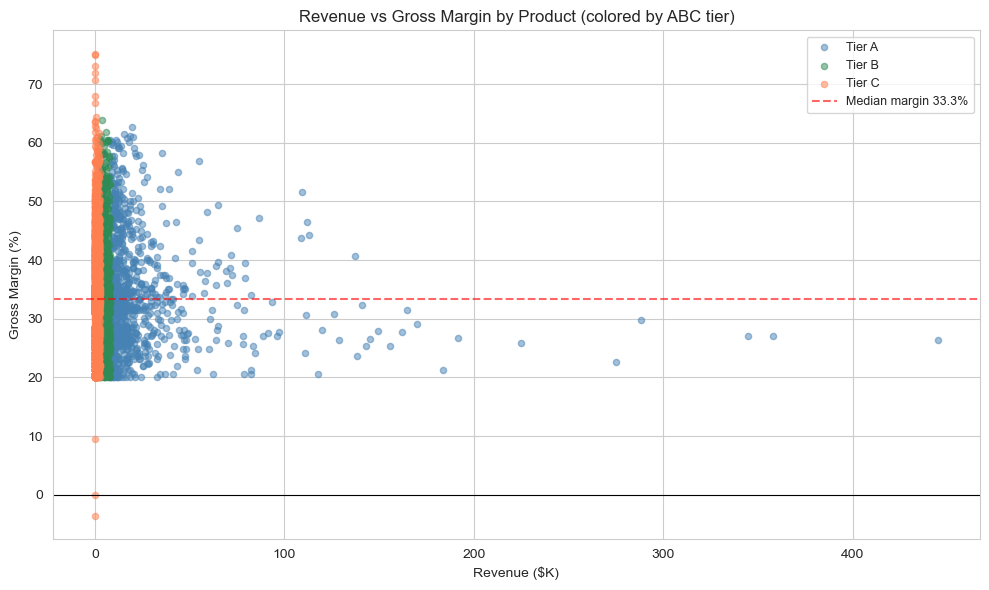

In [5]:
plot_df = product_margin.merge(abc[['Brand','ABC']], on='Brand', how='left')
plot_df = plot_df[plot_df['revenue'] > 0].dropna(subset=['avg_margin'])

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'A':'steelblue','B':'seagreen','C':'coral','nan':'grey'}

for tier in ['A','B','C']:
    d = plot_df[plot_df['ABC'] == tier]
    ax.scatter(d['revenue']/1e3, d['avg_margin'].clip(-20, 80),
               alpha=0.5, s=20, label=f'Tier {tier}', color=colors[tier])

ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(product_margin['avg_margin'].median(), color='red', linestyle='--', alpha=0.6,
           label=f'Median margin {product_margin["avg_margin"].median():.1f}%')
ax.set_xlabel('Revenue ($K)')
ax.set_ylabel('Gross Margin (%)')
ax.set_title('Revenue vs Gross Margin by Product (colored by ABC tier)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot_margin_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

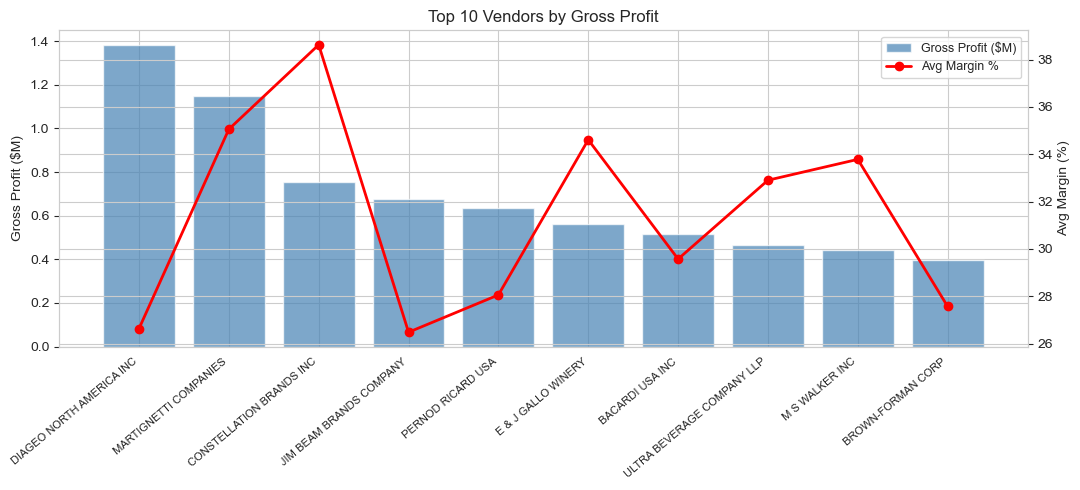

In [6]:
vendor_margin = (
    sales.groupby('VendorName')
    .agg(
        revenue      = ('SalesDollars','sum'),
        gross_profit = ('gross_profit','sum'),
        avg_margin   = ('margin','median')
    )
    .reset_index()
    .dropna(subset=['avg_margin'])
    .sort_values('gross_profit', ascending=False)
)

top_vm = vendor_margin.head(10)
fig, ax = plt.subplots(figsize=(11, 5))
names = [n[:28] + '...' if len(n) > 28 else n for n in top_vm['VendorName']]
x = np.arange(len(names))

ax2 = ax.twinx()
ax.bar(x, top_vm['gross_profit']/1e6, color='steelblue', alpha=0.7, label='Gross Profit ($M)')
ax2.plot(x, top_vm['avg_margin'], marker='o', color='red', linewidth=2, label='Avg Margin %')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Gross Profit ($M)')
ax2.set_ylabel('Avg Margin (%)')
ax.set_title('Top 10 Vendors by Gross Profit')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('plot_vendor_margin.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
beg_stock = beg_inv.groupby('Brand')['onHand'].sum().reset_index()
beg_stock.columns = ['Brand','beg_stock']

end_stock = end_inv.groupby('Brand')['onHand'].sum().reset_index()
end_stock.columns = ['Brand','end_stock']

purchased = purchases.groupby('Brand')['Quantity'].sum().reset_index()
purchased.columns = ['Brand','purchased']

sold = sales.groupby('Brand')['SalesQuantity'].sum().reset_index()
sold.columns = ['Brand','sold']

shrink = (
    beg_stock
    .merge(purchased, on='Brand', how='outer')
    .merge(sold,      on='Brand', how='outer')
    .merge(end_stock, on='Brand', how='outer')
    .fillna(0)
)

shrink['shrinkage'] = shrink['beg_stock'] + shrink['purchased'] - shrink['sold'] - shrink['end_stock']
shrink = shrink.merge(abc[['Brand','Description']], on='Brand', how='left')

total_shrinkage = shrink['shrinkage'].sum()
total_purchased = shrink['purchased'].sum()
shrink_rate = total_shrinkage / (shrink['beg_stock'].sum() + total_purchased) * 100

print(f'Total shrinkage (units): {total_shrinkage:,.0f}')
print(f'Shrinkage rate:          {shrink_rate:.2f}%')
print(f'\nProducts with shrinkage > 0: {(shrink["shrinkage"] > 0).sum()}')
print(f'Products with negative shrinkage: {(shrink["shrinkage"] < 0).sum()} (likely data/timing issues)')

Total shrinkage (units): 30,466,707
Shrinkage rate:          80.59%

Products with shrinkage > 0: 11020
Products with negative shrinkage: 0 (likely data/timing issues)


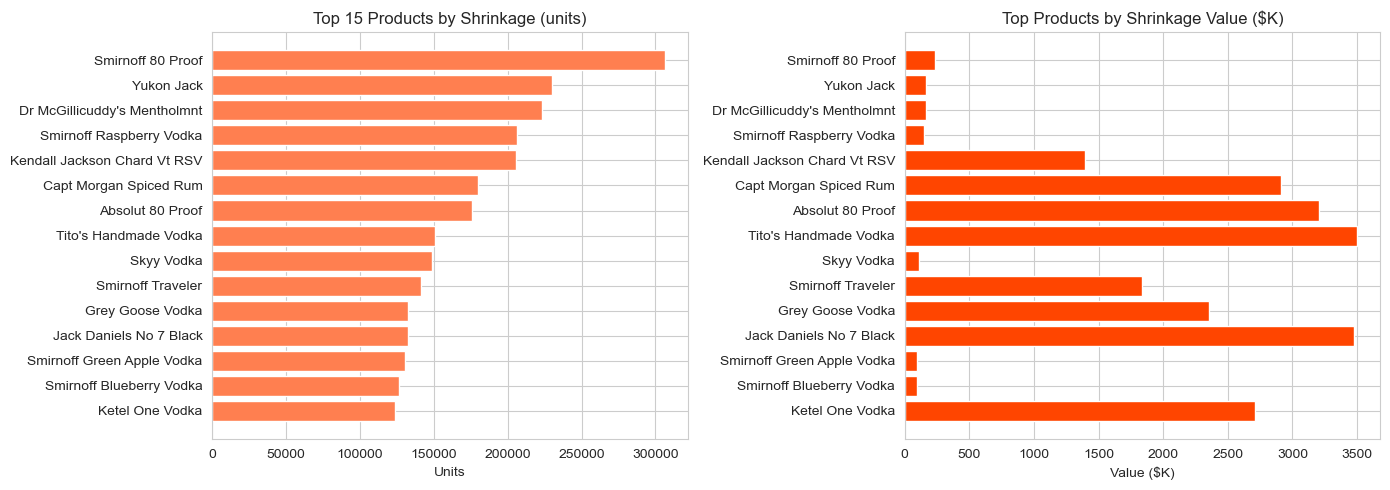

In [8]:
high_shrink = shrink[shrink['shrinkage'] > 0].nlargest(15, 'shrinkage')
high_shrink = high_shrink.merge(brand_cost, on='Brand', how='left')
high_shrink['shrink_value'] = high_shrink['shrinkage'] * high_shrink['unit_cost']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

labels = [str(d)[:28] + '...' if len(str(d)) > 28 else str(d) for d in high_shrink['Description']]

ax1.barh(labels[::-1], high_shrink['shrinkage'].values[::-1], color='coral')
ax1.set_title('Top 15 Products by Shrinkage (units)')
ax1.set_xlabel('Units')

has_cost = high_shrink.dropna(subset=['shrink_value'])
cost_labels = [str(d)[:28] + '...' if len(str(d)) > 28 else str(d) for d in has_cost['Description']]
ax2.barh(cost_labels[::-1], has_cost['shrink_value'].values[::-1] / 1e3, color='orangered')
ax2.set_title('Top Products by Shrinkage Value ($K)')
ax2.set_xlabel('Value ($K)')

plt.tight_layout()
plt.savefig('plot_shrinkage.png', dpi=150, bbox_inches='tight')
plt.show()

16 vendors (12.5%) account for 80% of total purchase spend
Top 1 vendor: DIAGEO NORTH AMERICA INC — 15.8% of spend
Top 3 vendors: 32.0% of spend


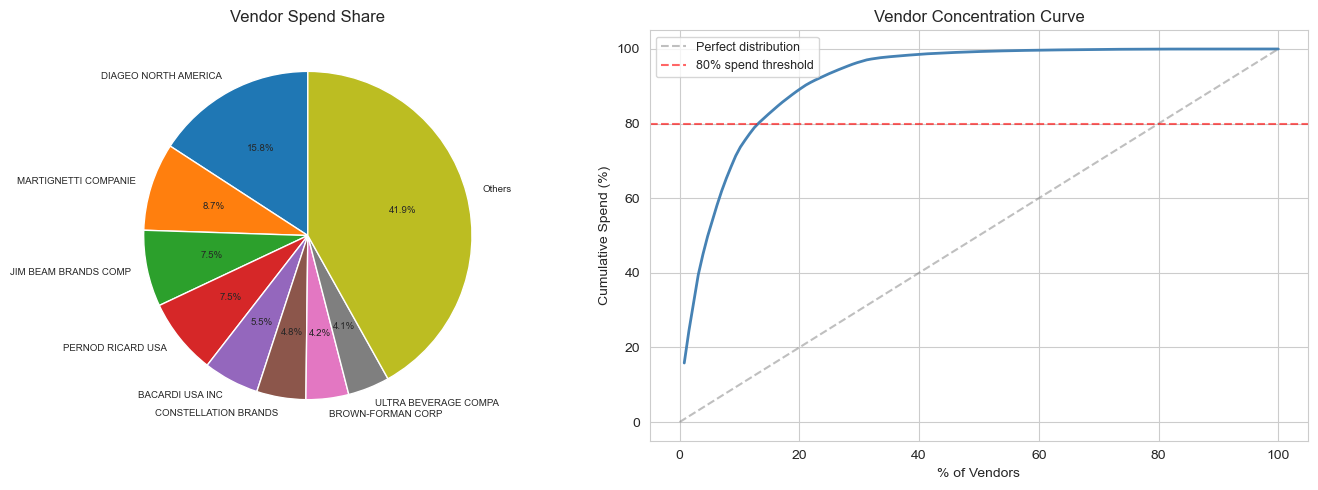

In [11]:
vendor_spend = (
    purchases.groupby('VendorName')
    .agg(spend=('Dollars','sum'), orders=('PONumber','nunique'))
    .reset_index()
    .sort_values('spend', ascending=False)
)

vendor_spend['spend_pct']   = vendor_spend['spend'] / vendor_spend['spend'].sum() * 100
vendor_spend['cum_pct']     = vendor_spend['spend_pct'].cumsum()
vendor_spend['vendor_rank_pct'] = np.arange(1, len(vendor_spend)+1) / len(vendor_spend) * 100

n_80 = (vendor_spend['cum_pct'] <= 80).sum()
n_total = len(vendor_spend)
print(f'{n_80} vendors ({n_80/n_total*100:.1f}%) account for 80% of total purchase spend')
print(f'Top 1 vendor: {vendor_spend.iloc[0]["VendorName"]} — {vendor_spend.iloc[0]["spend_pct"]:.1f}% of spend')
print(f'Top 3 vendors: {vendor_spend.head(3)["spend_pct"].sum():.1f}% of spend')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

top_v = vendor_spend.head(8).copy()
others = pd.DataFrame([{'VendorName':'Others', 'spend': vendor_spend.iloc[8:]['spend'].sum(),
                         'spend_pct': vendor_spend.iloc[8:]['spend_pct'].sum()}])
pie_data = pd.concat([top_v, others], ignore_index=True)

ax1.pie(pie_data['spend_pct'], labels=[n[:20] for n in pie_data['VendorName']],
        autopct='%1.1f%%', startangle=90, textprops={'fontsize':7})
ax1.set_title('Vendor Spend Share')

ax2.plot(vendor_spend['vendor_rank_pct'], vendor_spend['cum_pct'], color='steelblue', linewidth=2)
ax2.plot([0,100],[0,100], color='grey', linestyle='--', alpha=0.5, label='Perfect distribution')
ax2.axhline(80, color='red', linestyle='--', alpha=0.6, label='80% spend threshold')
ax2.set_xlabel('% of Vendors')
ax2.set_ylabel('Cumulative Spend (%)')
ax2.set_title('Vendor Concentration Curve')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_vendor_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

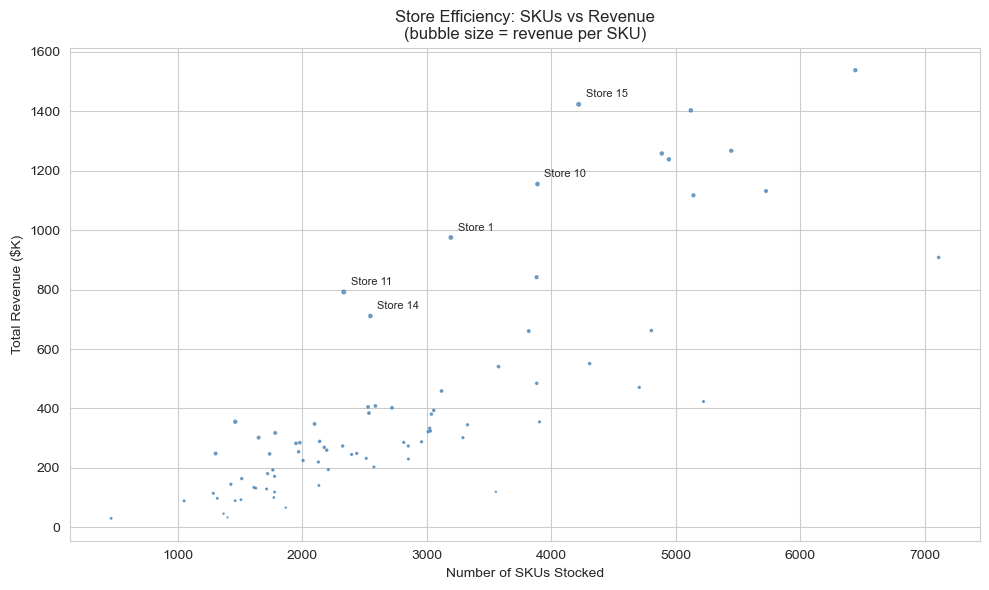

Top 10 most efficient stores (revenue per SKU):
 Store         City  sku_count    revenue  rev_per_sku
    11      CARDEND       2332  791786.64   339.531149
    15     WANBORNE       4219 1422998.94   337.283465
     1 HARDERSFIELD       3192  975115.86   305.487425
    10      HORNSEY       3888 1154926.80   297.049074
    14     BROMWICH       2546  711060.89   279.285503
    76    DONCASTER       5120 1402698.59   273.964568
    66   EANVERNESS       4887 1257824.93   257.381815
    38    GOULCREST       4944 1237991.19   250.402749
    13   TARMSWORTH       1460  355377.15   243.409007
    34    PITMERDEN       6442 1537806.51   238.715695


In [12]:
store_skus = end_inv.groupby('Store')['Brand'].nunique().reset_index()
store_skus.columns = ['Store','sku_count']

store_rev = sales.groupby('Store')['SalesDollars'].sum().reset_index()
store_rev.columns = ['Store','revenue']

store_eff = store_rev.merge(store_skus, on='Store', how='inner')
store_eff['rev_per_sku'] = store_eff['revenue'] / store_eff['sku_count']

store_city = beg_inv.drop_duplicates('Store')[['Store','City']]
store_eff = store_eff.merge(store_city, on='Store', how='left')

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(store_eff['sku_count'], store_eff['revenue']/1e3,
                s=store_eff['rev_per_sku']/50, alpha=0.7, color='steelblue')

for _, r in store_eff.nlargest(5,'rev_per_sku').iterrows():
    ax.annotate(f"Store {int(r['Store'])}",
                (r['sku_count'], r['revenue']/1e3),
                textcoords='offset points', xytext=(5,5), fontsize=8)

ax.set_xlabel('Number of SKUs Stocked')
ax.set_ylabel('Total Revenue ($K)')
ax.set_title('Store Efficiency: SKUs vs Revenue\n(bubble size = revenue per SKU)')
plt.tight_layout()
plt.savefig('plot_store_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most efficient stores (revenue per SKU):')
print(store_eff.nlargest(10,'rev_per_sku')[['Store','City','sku_count','revenue','rev_per_sku']]
      .to_string(index=False))

               Classification     revenue  excise_tax  tax_rate
   Classification 1 (Spirits) 20550829.07  1248429.75  6.074839
Classification 2 (Wine/Other) 12588546.22   142868.90  1.134912


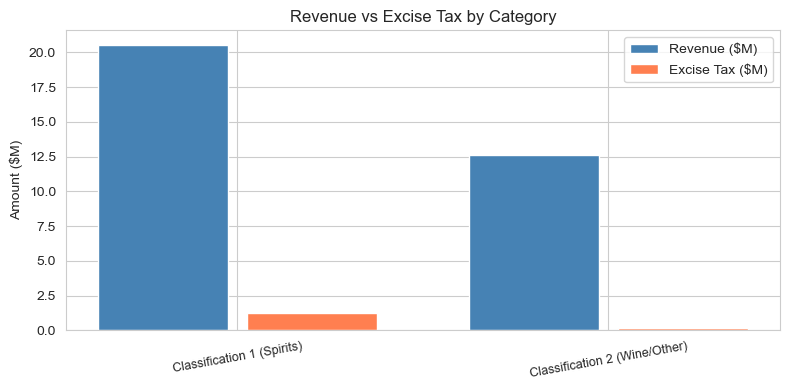

In [13]:
tax_by_class = (
    sales.groupby('Classification')
    .agg(revenue=('SalesDollars','sum'),
         excise_tax=('ExciseTax','sum'),
         units=('SalesQuantity','sum'))
    .reset_index()
)
tax_by_class['tax_rate'] = tax_by_class['excise_tax'] / tax_by_class['revenue'] * 100
tax_by_class['Classification'] = tax_by_class['Classification'].map(
    {1: 'Classification 1 (Spirits)', 2: 'Classification 2 (Wine/Other)'}
)

print(tax_by_class[['Classification','revenue','excise_tax','tax_rate']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8,4))
x = np.arange(2)
ax.bar(x - 0.2, tax_by_class['revenue']/1e6, 0.35, label='Revenue ($M)', color='steelblue')
ax.bar(x + 0.2, tax_by_class['excise_tax']/1e6, 0.35, label='Excise Tax ($M)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(tax_by_class['Classification'], rotation=10, fontsize=9)
ax.set_ylabel('Amount ($M)')
ax.set_title('Revenue vs Excise Tax by Category')
ax.legend()
plt.tight_layout()
plt.savefig('plot_excise_tax.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
top_vendor_name = vendor_spend.iloc[0]['VendorName']
top_vendor_pct  = vendor_spend.iloc[0]['spend_pct']
top3_pct        = vendor_spend.head(3)['spend_pct'].sum()
shrink_val      = high_shrink['shrink_value'].sum() if 'shrink_value' in high_shrink.columns else 0

print(top_vendor_name)
print(top_vendor_pct)
print(top3_pct)
print(shrink_val)

DIAGEO NORTH AMERICA INC
15.830902659114903
32.00509254781454
22415338.55
